# Multi-Asset Repricing: The Prayer Workflow

This notebook demonstrates the full Prayer (Meucci 2011) chain:
**Invariants → Estimate → Project → Reprice → Optimise**
for stocks, bonds, and options in a single portfolio.

In [1]:
import numpy as np
import pandas as pd
from pyvallocation import (
    project_scenarios, reprice_exp, reprice_taylor, make_repricing_fn,
    PortfolioWrapper,
)
from pyvallocation.plotting import plot_frontiers
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## P1: Invariants

| Instrument | Risk Driver | Invariant |
|---|---|---|
| Stock/ETF | log price | log return |
| Bond | yield | yield change |
| Option | log price + log implied vol | joint changes |

In [2]:
# Simulate daily invariants (in practice: extract from market data)
T = 500
stock_inv = rng.normal(0.0005, 0.015, (T, 1))        # daily log returns
yield_inv = rng.normal(0.0, 0.003, (T, 1))            # daily yield changes
option_inv = rng.multivariate_normal(                  # (log-return, vol-change)
    [0.0005, 0.0], [[0.015**2, 0], [0, 0.005**2]], T
)
print(f"Stock invariants: {stock_inv.shape}")
print(f"Yield invariants: {yield_inv.shape}")
print(f"Option invariants: {option_inv.shape}")

Stock invariants: (500, 1)
Yield invariants: (500, 1)
Option invariants: (500, 2)


## P3+P4: Project to 1-month horizon and reprice

In [3]:
horizon = 21  # trading days
n_sim = 3000

# Stock: exact repricing via exp(Δy) - 1
stock_scen = project_scenarios(stock_inv, horizon, n_simulations=n_sim, reprice=reprice_exp)

# Bond: full repricing via user pricing function
maturity = 10
bond_price = lambda Y: 100 * np.exp(-Y * maturity)
bond_scen = project_scenarios(
    yield_inv, horizon, n_simulations=n_sim,
    reprice=make_repricing_fn(bond_price, np.array([0.04])),
)

# Normalize bond P&L to percentage return (divide by initial bond price)
bond_scen_pct = bond_scen / bond_price(np.array([0.04]))

# Option: delta-gamma-theta Taylor approximation
delta, gamma, vega, theta = 0.55, 0.03, 0.15, -0.02
option_scen = project_scenarios(
    option_inv, horizon, n_simulations=n_sim,
    reprice=lambda dy: reprice_taylor(
        dy, delta=np.array([delta, vega]),
        gamma=np.array([gamma, 0.0]),
        theta=theta, tau=horizon/252,
    ),
)

# Normalize option P&L to percentage return (divide by notional option price)
option_price_0 = 5.0  # assumed initial option price in dollars
option_scen_pct = option_scen / option_price_0
# Sum across risk drivers to get single-instrument P&L
option_scen_pct = option_scen_pct.sum(axis=1, keepdims=True)

for name, s in [("Stock", stock_scen), ("Bond", bond_scen), ("Option", option_scen)]:
    print(f"{name:8s}  mean={np.mean(s):+.4f}  std={np.std(s):.4f}")

print("\nAfter normalizing to percentage returns:")
for name, s in [("Stock", stock_scen), ("Bond (pct)", bond_scen_pct), ("Option (pct)", option_scen_pct)]:
    print(f"{name:12s}  mean={np.mean(s):+.6f}  std={np.std(s):.6f}")

Stock     mean=+0.0101  std=0.0689
Bond      mean=+2.7506  std=10.1273
Option    mean=-0.0100  std=0.0277

After normalizing to percentage returns:
Stock         mean=+0.010051  std=0.068859
Bond (pct)    mean=+0.041034  std=0.151082
Option (pct)  mean=-0.003993  std=0.007507


## P5-P8: Combine and optimise

Estimating mu and cov from scenarios (no explicit values provided).


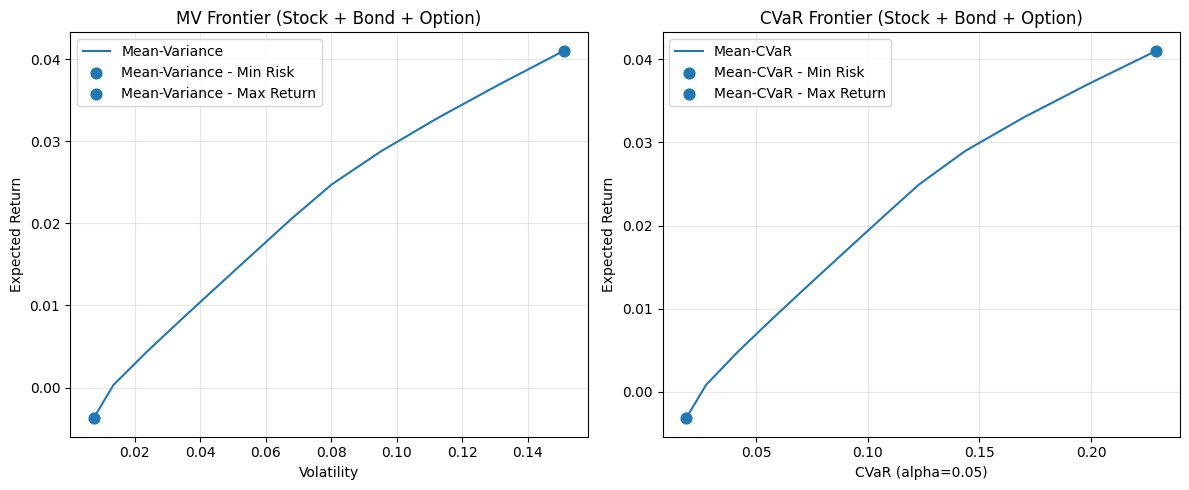

In [4]:
all_scen = np.column_stack([stock_scen, bond_scen_pct, option_scen_pct])
wrapper = PortfolioWrapper.from_scenarios(all_scen)

mv = wrapper.variance_frontier(num_portfolios=12)
cvar = wrapper.cvar_frontier(num_portfolios=12, alpha=0.05, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_frontiers(mv, labels=["Mean-Variance"], ax=axes[0])
axes[0].set_title("MV Frontier (Stock + Bond + Option)")
plot_frontiers(cvar, labels=["Mean-CVaR"], ax=axes[1])
axes[1].set_title("CVaR Frontier (Stock + Bond + Option)")
fig.tight_layout()
plt.show()

In [5]:
w_mv, ret_mv, risk_mv = mv.min_risk()
w_cvar, ret_cvar, risk_cvar = cvar.min_risk()

result = pd.DataFrame({
    "Min-Variance": w_mv,
    "Min-CVaR": w_cvar,
})
result.index = ["Stock", "Bond", "Option"]
print(result.round(3))
print(f"\nMV:   return={ret_mv:.4f}, vol={risk_mv:.4f}")
print(f"CVaR: return={ret_cvar:.4f}, CVaR={risk_cvar:.4f}")


        Min-Variance  Min-CVaR
Stock          0.009     0.022
Bond           0.002     0.011
Option         0.988     0.967

MV:   return=-0.0038, vol=0.0075
CVaR: return=-0.0032, CVaR=0.0186
